In [1]:
import numpy as np
from CoPhaser import utils
from CoPhaser.trainer import Trainer
from CoPhaser.loss import Loss
from CoPhaser import plotting
from CoPhaser.model import CoPhaser
from CoPhaser import gene_sets
from CoPhaser.model import VAEModelLoader
import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import anndata
import scanpy as sc

import pandas as pd

DATA_FOLDER = "../../data/"

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
adata = anndata.read_h5ad(f"{DATA_FOLDER}/aorta_circadian/adata_concatenated.h5ad")
adata

AnnData object with n_obs × n_vars = 22573 × 32285
    obs: 'batch', 'sample_id', 'sex', 'misaligned', 'zt', 'percent_mito', 'lib_size', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mito_qc_pass', 'umi_qc_pass', 'doublet_qc_pass', 'doublet_score', 'qc_pass', 'cluster', 'subcluster', 'log_L', 'phase', 'celltype'
    obsm: '2d_embedding', 'denoised_log_dispersion_hat', 'denoised_log_mean_hat', 'embedding'

<Axes: ylabel='Count'>

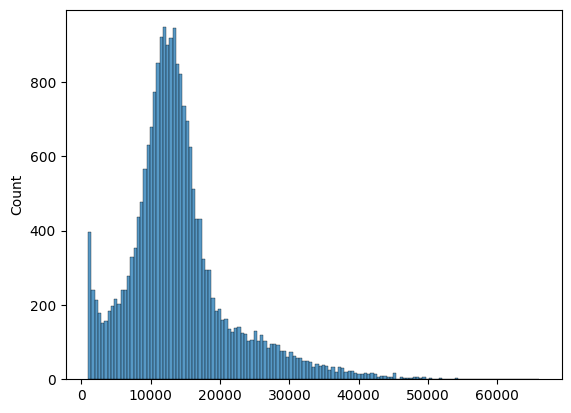

In [4]:
adata.layers["total"] = adata.X.copy()
adata = adata[adata.obs["qc_pass"]].copy()
layer_to_use = "total"
library_size = adata.layers[layer_to_use].sum(axis=1).A1
sns.histplot(x=library_size)

In [5]:
# replace Arntl by Bmal1
var_names = adata.var_names.tolist()
var_names[var_names.index("Arntl")] = "Bmal1"
adata.var_names = var_names

In [6]:
SMALL_CYCLING_GENE_SET = gene_sets.SMALL_CIRCADIAN_GENE_SET

In [7]:
g = utils.get_variable_genes(adata, 2000)
len(g)

2000

In [8]:
genes_tempo = [
    "Arntl",
    "Arntl2",
    "Bhlhe41",
    "Ciart",
    "Clock",
    "Cry1",
    "Cry2",
    "Csnk1a1",
    "Csnk1d",
    "Csnk1e",
    "Dbp",
    "Dec1",
    "Dec2",
    "Fbxo21",
    "Fbxo3",
    "Gm129",
    "Hlf",
    "Nampt",
    "Nfil3",
    "Npas2",
    "Nr1d1",
    "Nr1d2",
    "Per1",
    "Per2",
    "Per3",
    "Rora",
    "Rorc",
    "Tef",
]

In [9]:
SMALL_CYCLING_GENE_SET = np.array(
    list(
        set(list(gene_sets.SMALL_CIRCADIAN_GENE_SET) + genes_tempo)
        & set(adata.var_names)
    )
)

In [10]:
len(SMALL_CYCLING_GENE_SET)

25

In [11]:
amp_phase_circadian = {
    "Bmal1": (1, 5.5),
    "Npas2": (0.5, 5.5),
    "Rorc": (0.5, 5.7),
    "Nr1d1": (1, 2.0),
    "Nr1d2": (0.75, 2.09),
    "Tef": (0.75, 2.35),
    "Ciart": (1, 2.35),
    "Dbp": (1, 2.09),
    "Per3": (1, 2.36),
    "Cry1": (0.5, 4.71),
    "Cry2": (0.25, 3),
    "Per2": (0.6, 3.14),
    "Per1": (0.5, 3.14),
    "Hlf": (0.5, 3.14),
}

In [12]:
def optimal_shift(p, p0, n_s=200):
    """
    Aligns two sequences defined on the unit circle, taking care of the periodicity
    and the flipping symmetry of the circle.
    It uses the median absolute deviation (MAD) as a measure of the distance between the two sequences.

    Parameters:
    p: phase array to adjust
    p0: phase array (reference)
    n_s: number of shifts to consider

    Returns:
    phi_aligned: the aligned phase array
    best_mad: the MAD of the best alignment
    """

    def circular_deviation2(x, y, period=2 * np.pi):
        """
        Function called by optimal_shift
        Inputs:
        x: phase array
        y: phase array
        period: period of the circular variable
        """
        x, y = x % period, y % period
        v1 = np.abs(x - y)
        v2 = (period - v1) % period

        return np.minimum(v1, v2)

    Nc = p.shape[0]
    shifts = np.linspace(0, 2 * np.pi, n_s)
    # creating a matrix of all possible shifts
    theta_cs = (p.reshape(Nc, 1) - shifts.reshape(1, n_s)) % (2 * np.pi)
    theta_cs_neg = (-p.reshape(Nc, 1) - shifts.reshape(1, n_s)) % (2 * np.pi)

    # for each shift, computing the circular deviation, using apply_along_axis
    delta_cs = circular_deviation2(p0[:, None], theta_cs)
    delta_cs_neg = circular_deviation2(p0[:, None], theta_cs_neg)

    # computing the median absolute deviation for all shifts
    v = np.median(delta_cs, axis=0)
    v_neg = np.median(delta_cs_neg, axis=0)
    # selecting the best shift
    best_shift_ind = np.argmin(v)
    best_shift_ind_neg = np.argmin(v_neg)
    mad, mad_neg = v[best_shift_ind], v_neg[best_shift_ind_neg]

    # selecting which direction is the best
    if mad < mad_neg:
        phi_aligned = theta_cs[:, best_shift_ind]
        best_mad = mad
    else:
        phi_aligned = theta_cs_neg[:, best_shift_ind_neg]
        best_mad = mad_neg

    return phi_aligned, best_mad


def get_MAD(adata, thetas):
    w = 2 * np.pi / 24
    true_phase = (adata.obs.zt.values % 24) * w
    if not isinstance(thetas, np.ndarray):
        thetas = thetas.detach().numpy()
    phi = thetas % (2 * np.pi)

    _, mad = optimal_shift(phi, true_phase)
    return mad / w

Epoch 1/200, elbo_loss: 1768.0766, kl_div_f: 4.6776, kl_div_z: 25.8081, fraction_cycling_cells: 1.0000, l2_px_rate: 0.0000, entropy_loss_unweighted: -2.7551, entropy_loss: -137.7556, radial_variance: 0.0000, radius: 0.0000, L1_mu_z: 0.0000, MI_loss: 0.0000, total_loss: 1630.3210
Epoch 2/200, elbo_loss: 1509.1738, kl_div_f: 4.6237, kl_div_z: 34.3453, fraction_cycling_cells: 1.0000, l2_px_rate: 0.0000, entropy_loss_unweighted: -3.1059, entropy_loss: -155.2942, radial_variance: 0.0000, radius: 0.0000, L1_mu_z: 0.0000, MI_loss: 0.0005, total_loss: 1353.9023
Epoch 3/200, elbo_loss: 1464.1108, kl_div_f: 4.5662, kl_div_z: 34.5495, fraction_cycling_cells: 1.0000, l2_px_rate: 0.0000, entropy_loss_unweighted: -3.3721, entropy_loss: -168.6053, radial_variance: 0.0000, radius: 0.0000, L1_mu_z: 0.0000, MI_loss: 0.0013, total_loss: 1295.5698
Epoch 4/200, elbo_loss: 1429.5522, kl_div_f: 4.5022, kl_div_z: 33.8286, fraction_cycling_cells: 1.0000, l2_px_rate: 0.0000, entropy_loss_unweighted: -3.3957, en

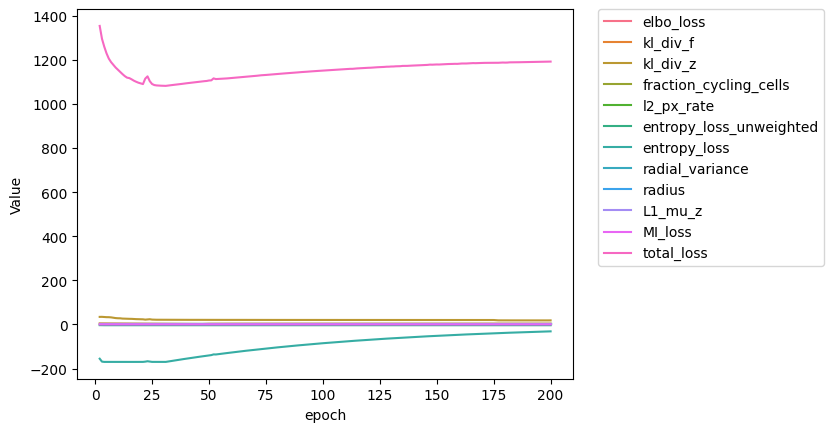

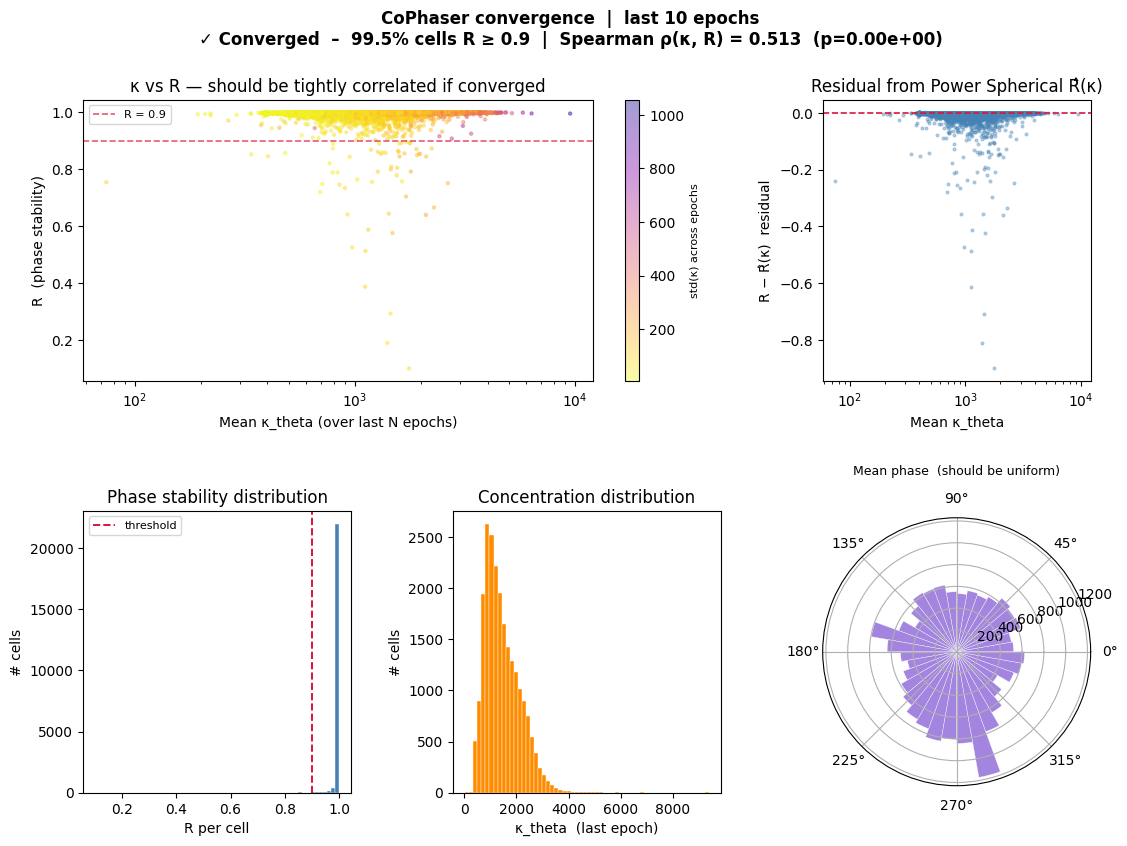


── Convergence summary ───────────────────────────────
  converged               True
  fraction_stable         0.9946396136977805
  mean_R                  0.9961118102073669
  spearman_kappa_R        0.5128325374513533
  spearman_pval           0.0
  mean_kappa_last         1462.2528076171875
  n_epochs_tracked        10
  n_cells_excluded_nan    0
──────────────────────────────────────────────────────

MAD for endothelial: 3.3885137654864095
MAD for fibroblast: 2.4515441241238984
MAD for macrophage: 2.4450962419025943
MAD for smc: 1.8968684020373001


In [13]:
celltypes = adata.obs["celltype"].unique().tolist()
model = CoPhaser(
    SMALL_CYCLING_GENE_SET,
    g,
    n_latent=10,
    n_harm=1,
)
model.load_anndata(adata, layer_to_use="total")

VAEModelLoader.define_decoder_prior(amp_phase_prior=amp_phase_circadian, model=model)
trainer = Trainer(
    model,
    Loss.compute_loss,
    non_rhythmic_likelihood_weight=2,
    rhythmic_likelihood_weight=10,
    unfreeze_epoch_layer=[(10, "rhythmic_decoder")],
    L2_Z_decoder_loss_weight=0,
    closed_circle_weight=0,
    MI_weight=50,
    entropy_weight_factor=50,
    cycling_status_prior=1,
    MI_detach="f",
)
trainer.train_model(
    n_epochs=200,
    lr=1e-2,
    device="cuda",
    batch_size=2048,
)
# Get the infered theta values
model.to("cpu")
generative_outputs, space_outputs = model.get_outputs()
# thetas = model.infer_pseudotimes(adata,"total",False)
thetas_unrefined = space_outputs["theta"].detach().cpu().numpy()
for ct in celltypes:
    i = adata.obs["celltype"] == ct
    print(f"MAD for {ct}: {get_MAD(adata[i], thetas_unrefined[i])}")

In [14]:
from CoPhaser import pseudo_r2

res = pseudo_r2.fit_cyclic_r2_celltypes(
    adata.layers["total"],
    thetas_unrefined,
    space_outputs["z"].detach().cpu().numpy(),
    adata.var_names,
    aggregation="mean",
    labels=adata.obs["celltype"].values,
)

In [16]:
res.sort_values("r2", ascending=False).head(20)

,gene,r2,signal,noise,peak_phase,n_clusters_used,mean_cluster_size,intersection
12235,Dbp,0.652946,5.877583,2.633026,2.300549,4,2500,4
20124,Nr1d1,0.609945,1.408952,0.742088,1.361320,4,2500,4
25741,Tef,0.321244,0.361158,1.014209,2.697967,4,2500,4
23704,Nr1d2,0.281245,0.402449,0.727958,2.359108,4,2500,3
7369,Per3,0.251685,0.259954,0.608502,2.815905,4,2500,3
19949,Hlf,0.244954,0.639283,1.450413,2.705667,4,2500,3
13145,Bmal1,0.197401,0.034661,0.140876,6.156117,4,2500,3
13642,Tspan4,0.170513,0.329029,1.686405,2.913709,4,2500,4
30425,Rbm3,0.159245,0.710932,3.333086,2.378448,4,2500,3
15967,Zbtb16,0.135017,0.344207,1.029800,2.524365,4,2500,3


In [17]:
res[res["intersection"] > 1].sort_values("r2", ascending=False).head(20)

,gene,r2,signal,noise,peak_phase,n_clusters_used,mean_cluster_size,intersection
12235,Dbp,0.652946,5.877583,2.633026,2.300549,4,2500,4
20124,Nr1d1,0.609945,1.408952,0.742088,1.361320,4,2500,4
25741,Tef,0.321244,0.361158,1.014209,2.697967,4,2500,4
23704,Nr1d2,0.281245,0.402449,0.727958,2.359108,4,2500,3
7369,Per3,0.251685,0.259954,0.608502,2.815905,4,2500,3
19949,Hlf,0.244954,0.639283,1.450413,2.705667,4,2500,3
13145,Bmal1,0.197401,0.034661,0.140876,6.156117,4,2500,3
13642,Tspan4,0.170513,0.329029,1.686405,2.913709,4,2500,4
30425,Rbm3,0.159245,0.710932,3.333086,2.378448,4,2500,3
15967,Zbtb16,0.135017,0.344207,1.029800,2.524365,4,2500,3


In [18]:
def get_log_normalized_counts(adata, gene, layer_to_use="total"):
    """
    Returns the log normalized counts of the gene
    """
    counts = np.asarray(adata[:, gene].layers[layer_to_use].toarray()).flatten()
    library_size = np.asarray(adata.layers[layer_to_use].sum(axis=1)).flatten()
    log_normalized_counts = np.log1p(counts / library_size * 1e4)
    return log_normalized_counts

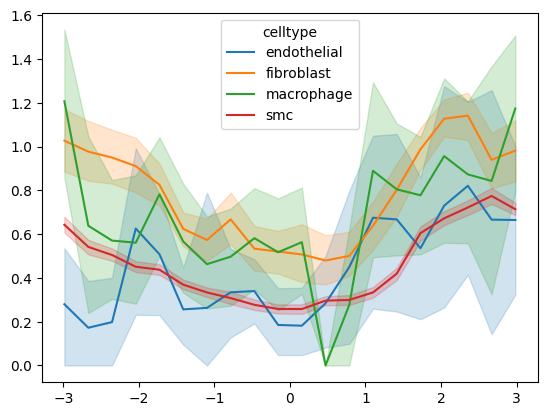

In [25]:
plotting.plot_smoothed_profiles(
    x=thetas_unrefined,
    y=get_log_normalized_counts(adata, "Tspan4"),
    nbins=20,
    ax=plt.gca(),
    hue=adata.obs["celltype"],
)

In [22]:
to_add = (
    res[(res["intersection"] > 1) & (res["r2"] > 0.1)]
    .sort_values("r2", ascending=False)["gene"]
    .to_list()
)

In [23]:
to_add

['Dbp',
 'Nr1d1',
 'Tef',
 'Nr1d2',
 'Per3',
 'Hlf',
 'Bmal1',
 'Tspan4',
 'Rbm3',
 'Zbtb16',
 'Npas2',
 'Fkbp5',
 'Per2',
 'Nfil3',
 'Thra',
 'Bhlhe41']

In [24]:
[g for g in to_add if g not in SMALL_CYCLING_GENE_SET]

['Tspan4', 'Rbm3', 'Zbtb16', 'Fkbp5', 'Thra']

Epoch 1/200, elbo_loss: 1928.6858, kl_div_f: 4.6774, kl_div_z: 27.2772, fraction_cycling_cells: 1.0000, l2_px_rate: 0.0000, entropy_loss_unweighted: -2.5747, entropy_loss: -128.7325, radial_variance: 0.0000, radius: 0.0000, L1_mu_z: 0.0000, MI_loss: 0.0000, total_loss: 1799.9533
Epoch 2/200, elbo_loss: 1574.5083, kl_div_f: 4.6255, kl_div_z: 37.1152, fraction_cycling_cells: 1.0000, l2_px_rate: 0.0000, entropy_loss_unweighted: -2.6961, entropy_loss: -134.8031, radial_variance: 0.0000, radius: 0.0000, L1_mu_z: 0.0000, MI_loss: 0.0003, total_loss: 1439.7214
Epoch 3/200, elbo_loss: 1530.9169, kl_div_f: 4.5666, kl_div_z: 37.0765, fraction_cycling_cells: 1.0000, l2_px_rate: 0.0000, entropy_loss_unweighted: -2.9109, entropy_loss: -145.5462, radial_variance: 0.0000, radius: 0.0000, L1_mu_z: 0.0000, MI_loss: 0.0018, total_loss: 1385.4599
Epoch 4/200, elbo_loss: 1513.2520, kl_div_f: 4.5022, kl_div_z: 37.3298, fraction_cycling_cells: 1.0000, l2_px_rate: 0.0000, entropy_loss_unweighted: -3.3075, en

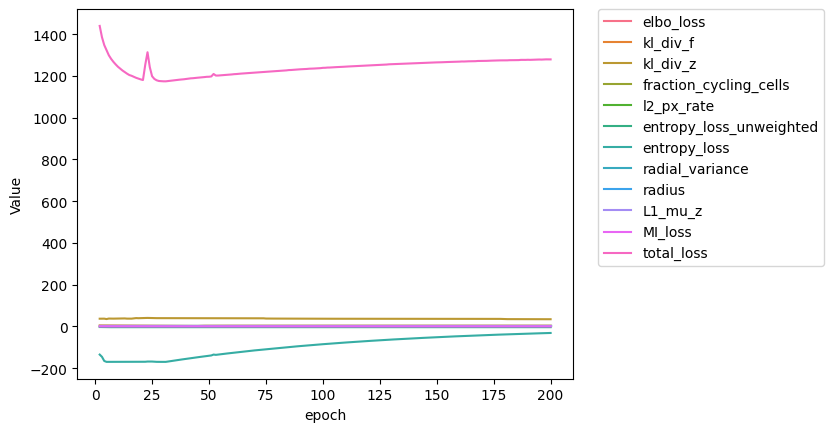

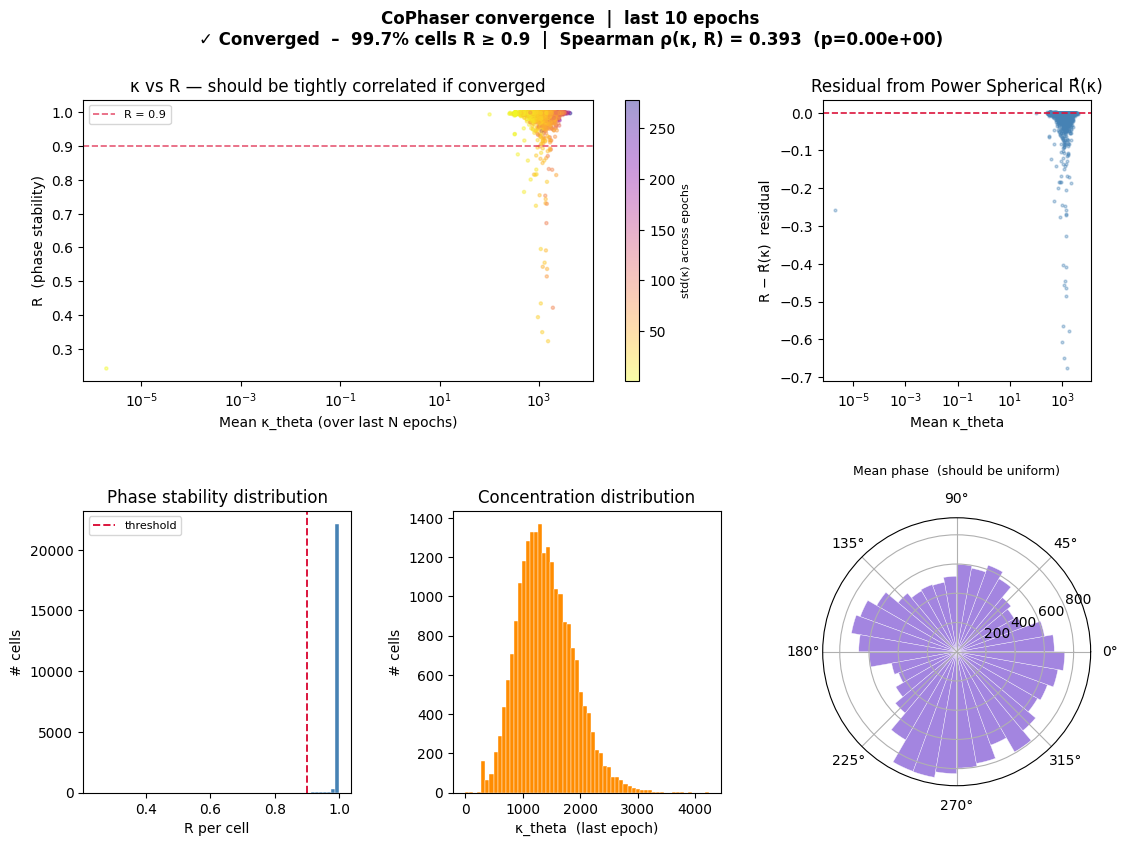


── Convergence summary ───────────────────────────────
  converged               True
  fraction_stable         0.9965002436539229
  mean_R                  0.9971343874931335
  spearman_kappa_R        0.3934449265944047
  spearman_pval           0.0
  mean_kappa_last         1403.45068359375
  n_epochs_tracked        10
  n_cells_excluded_nan    0
──────────────────────────────────────────────────────

MAD for endothelial: 3.0840112043963765
MAD for fibroblast: 2.179112578852359
MAD for macrophage: 2.09403437346979
MAD for smc: 1.5136175420868136


In [26]:
celltypes = adata.obs["celltype"].unique().tolist()
model = CoPhaser(
    np.union1d(SMALL_CYCLING_GENE_SET, to_add),
    g,
    n_latent=10,
    n_harm=1,
)
model.load_anndata(adata, layer_to_use="total")

VAEModelLoader.define_decoder_prior(amp_phase_prior=amp_phase_circadian, model=model)
trainer = Trainer(
    model,
    Loss.compute_loss,
    non_rhythmic_likelihood_weight=2,
    rhythmic_likelihood_weight=10,
    unfreeze_epoch_layer=[(10, "rhythmic_decoder")],
    L2_Z_decoder_loss_weight=0,
    closed_circle_weight=0,
    MI_weight=50,
    entropy_weight_factor=50,
    cycling_status_prior=1,
    MI_detach="f",
)
trainer.train_model(
    n_epochs=200,
    lr=1e-2,
    device="cuda",
    batch_size=2048,
)
# Get the infered theta values
model.to("cpu")
generative_outputs, space_outputs = model.get_outputs()
# thetas = model.infer_pseudotimes(adata,"total",False)
thetas = space_outputs["theta"].detach().cpu().numpy()
for ct in celltypes:
    i = adata.obs["celltype"] == ct
    print(f"MAD for {ct}: {get_MAD(adata[i], thetas[i])}")

In [29]:
# save list of genes to add
pd.DataFrame({"gene": to_add}).to_csv("data/aorta_top_r2_genes.csv", index=False)

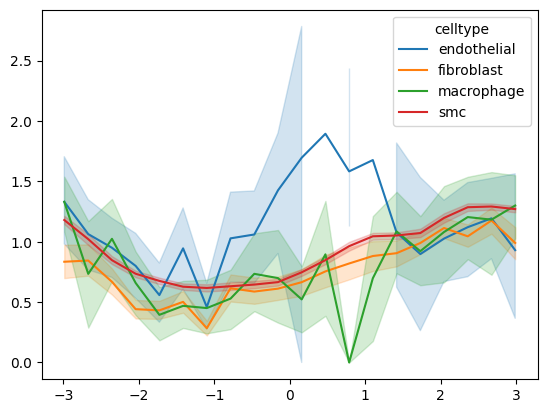

In [28]:
plotting.plot_smoothed_profiles(
    x=thetas,
    y=get_log_normalized_counts(adata, "Rbm3"),
    nbins=20,
    ax=plt.gca(),
    hue=adata.obs["celltype"],
)